<a href="https://colab.research.google.com/github/AileenLavelle/PBC_Object_Detection/blob/main/Jup_Wateronly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

!pip install sahi ultralytics
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel

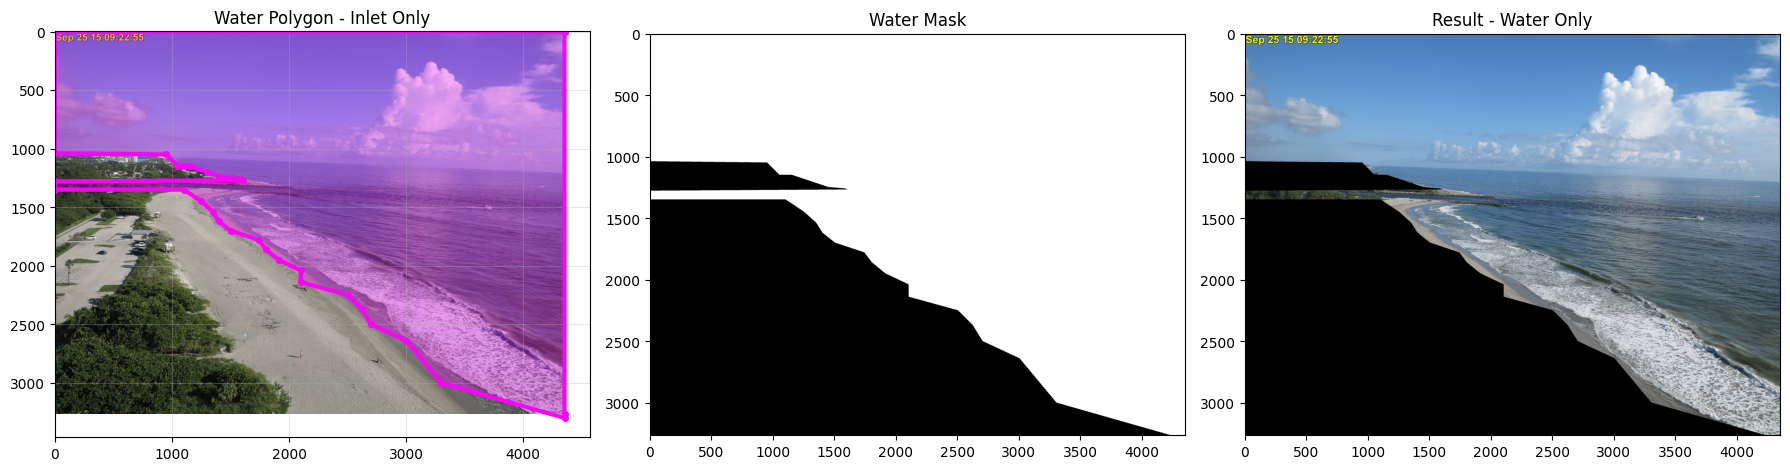

Water region: (0, 0, 4353, 3301)
Mask coverage: 64.9% of image

✓ Refined water polygon mask saved!
True


In [2]:
def create_polygon_mask_from_points(image_path, polygon_points):
    """
    Create mask from polygon points following the shoreline
    """
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create mask
    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    polygon = np.array(polygon_points, dtype=np.int32)
    cv2.fillPoly(mask, [polygon], 255)

    # Get bounding box
    x, y, w, h = cv2.boundingRect(polygon)
    water_bbox = (x, y, w, h)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_rgb)
    axes[0].plot(polygon[:, 0], polygon[:, 1], 'magenta', linewidth=3, marker='o', markersize=4)
    axes[0].plot([polygon[-1, 0], polygon[0, 0]],
                 [polygon[-1, 1], polygon[0, 1]], 'magenta', linewidth=3)
    axes[0].fill(polygon[:, 0], polygon[:, 1], 'magenta', alpha=0.3)
    axes[0].set_title('Water Polygon - Inlet Only')
    axes[0].grid(True, alpha=0.3)

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Water Mask')

    masked = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    axes[2].imshow(masked)
    axes[2].set_title('Result - Water Only')
    plt.tight_layout()
    plt.show()

    print(f"Water region: {water_bbox}")
    print(f"Mask coverage: {np.sum(mask > 0) / mask.size * 100:.1f}% of image")
    return mask, water_bbox

reference_image = "/content/Jupiter_Inlet/s250922w_jpg.rf.s2JZ1VgWg2GKNiAE6BEL.jpg"

# REFINED polygon - narrower left side to exclude land, keep inlet channel
water_polygon = [
    # Inlet mouth - narrower opening
    (0, 0),        # Top of inlet (moved right to exclude left land)
    (0, 1040),
    (950, 1050),
    (1050, 1150),
    (1100, 1150),
    (1150, 1150),
    (1300, 1200),
    (1450, 1250),
    (1580, 1260),
    (1610, 1270),
    (0, 1280),       # Narrow inlet channel
    (0, 1350),
    (1100, 1350),    # Where inlet widens
    (1250, 1450),
    (1350, 1540),
    (1400, 1620),
    (1500, 1700),    # Beach curve
    (1740, 1780),
    (1800, 1860),
    (1910, 1950),
    (2100, 2040),
    (2100, 2140),
    (2500, 2250),
    (2620, 2370),
    (2700, 2500),
    (3000, 2640),
    (3300, 3000),
    (4352, 3300),    # Bottom right
    (4352, 3264),
    (4352, 0),       # Top right corner
    (600, 0),        # Top edge (adjusted)
]

WATER_MASK, WATER_BBOX = create_polygon_mask_from_points(reference_image, water_polygon)

# Save the mask
np.save("/content/water_mask.npy", WATER_MASK)
np.save("/content/water_bbox.npy", WATER_BBOX)
np.save("/content/polygon_points.npy", np.array(water_polygon))
print("\n✓ Refined water polygon mask saved!")

import shapely.geometry as geom

poly = geom.Polygon(water_polygon)
print(poly.is_valid)

Crop dataset to water ROI

In [3]:
import json
import os
import cv2
import numpy as np
from tqdm import tqdm

# ---- paths ----
COCO_JSON = "/content/_annotations.coco.json"
IMG_DIR = "/content/Jupiter_Inlet"
OUT_DIR = "/content/Jupiter_Inlet/cropped_dataset"
OUT_IMG = os.path.join(OUT_DIR, "images")
OUT_JSON = os.path.join(OUT_DIR, "annotations.json")

os.makedirs(OUT_IMG, exist_ok=True)

# ---- load water ROI ----
x0, y0, w, h = np.load("water_bbox.npy")

# ---- load COCO ----
with open(COCO_JSON) as f:
    coco = json.load(f)

new_images = []
new_annotations = []

image_id_map = {}
new_ann_id = 1

print("Cropping images + annotations...")

for img in tqdm(coco["images"]):

    img_path = os.path.join(IMG_DIR, img["file_name"])
    frame = cv2.imread(img_path)

    if frame is None:
        print("Missing:", img_path)
        continue

    cropped = frame[y0:y0+h, x0:x0+w]
    cv2.imwrite(os.path.join(OUT_IMG, img["file_name"]), cropped)

    # new image entry
    new_img = img.copy()
    new_img["width"] = int(w)
    new_img["height"] = int(h)

    image_id_map[img["id"]] = img["id"]
    new_images.append(new_img)

# ---- shift annotations ----
for ann in coco["annotations"]:

    img_id = ann["image_id"]
    x, y, bw, bh = map(float, ann["bbox"])

    # shift to cropped coords
    x -= x0
    y -= y0

    # discard boxes outside crop
    if x + bw <= 0 or y + bh <= 0 or x >= w or y >= h:
        continue

    # clip box
    x = max(0, x)
    y = max(0, y)
    bw = min(bw, w - x)
    bh = min(bh, h - y)

    new_ann = ann.copy()
    new_ann["id"] = new_ann_id
    new_ann["bbox"] = [x, y, bw, bh]
    new_ann["area"] = bw * bh
    new_ann_id += 1

    new_annotations.append(new_ann)

# ---- save new COCO ----
new_coco = {
    "info": coco["info"],
    "licenses": coco["licenses"],
    "categories": coco["categories"],
    "images": new_images,
    "annotations": new_annotations
}

with open(OUT_JSON, "w") as f:
    json.dump(new_coco, f)

print("\n✓ Cropped COCO dataset saved to:", OUT_DIR)


Cropping images + annotations...


100%|██████████| 39/39 [00:06<00:00,  5.91it/s]


✓ Cropped COCO dataset saved to: /content/Jupiter_Inlet/cropped_dataset


YOLO format

In [4]:
import json
import os

COCO_JSON = "/content/Jupiter_Inlet/cropped_dataset/annotations.json"
OUT_LABELS = "cropped_dataset/labels"

os.makedirs(OUT_LABELS, exist_ok=True)

with open(COCO_JSON) as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}

for img in coco["images"]:

    W = img["width"]
    H = img["height"]
    name = img["file_name"].replace(".jpg", ".txt")

    lines = []

    for ann in coco["annotations"]:
        if ann["image_id"] != img["id"]:
            continue

        x, y, w, h = ann["bbox"]

        xc = (x + w/2) / W
        yc = (y + h/2) / H
        bw = w / W
        bh = h / H

        lines.append(f"0 {xc} {yc} {bw} {bh}")

    with open(os.path.join(OUT_LABELS, name), "w") as f:
        f.write("\n".join(lines))

print("✓ YOLO labels exported")


✓ YOLO labels exported


In [3]:
import cv2
import numpy as np
from sahi.predict import get_sliced_prediction
from sahi.auto_model import AutoDetectionModel

# ---- load mask + bbox ----
water_mask = np.load("water_mask.npy")
x0, y0, w, h = np.load("water_bbox.npy")

# ---- load model ----
model = AutoDetectionModel.from_pretrained(
    model_type="yolov11",
    model_path="yolo11n.pt",
    confidence_threshold=0.15,
    device="cuda"  # or "cpu"
)

def filter_by_mask(dets, mask):

    filtered = []

    for d in dets:
        x1, y1, x2, y2 = map(int, d.bbox.to_xyxy())

        cx = (x1 + x2)//2
        cy = (y1 + y2)//2

        if 0 <= cy < mask.shape[0] and 0 <= cx < mask.shape[1]:
            if mask[cy, cx] > 0:
                filtered.append(d)

    return filtered

def detect_boats(frame):

    # crop to water
    crop = frame[y0:y0+h, x0:x0+w]
    crop_mask = water_mask[y0:y0+h, x0:x0+w]

    result = get_sliced_prediction(
        crop,
        model,
        slice_height=768,
        slice_width=768,
        overlap_height_ratio=0.25,
        overlap_width_ratio=0.25
    )

    dets = filter_by_mask(result.object_prediction_list, crop_mask)

    return dets

def count_boats(frame):
    return len(detect_boats(frame))


In [4]:
def draw(frame):

    dets = detect_boats(frame)
    crop = frame[y0:y0+h, x0:x0+w].copy()

    for d in dets:
        x1, y1, x2, y2 = map(int, d.bbox.to_xyxy())
        cv2.rectangle(crop, (x1,y1), (x2,y2), (0,255,0), 2)

    print("Boats:", len(dets))
    cv2.imshow("detections", crop)
    cv2.waitKey(0)


In [7]:
import cv2
import numpy as np
from sahi.predict import get_sliced_prediction
from sahi.auto_model import AutoDetectionModel

# ---- load mask + bbox ----
water_mask = np.load("/content/water_mask.npy")
x0, y0, w, h = np.load("/content/water_bbox.npy")

print("Water bbox:", x0, y0, w, h)
print("Mask shape:", water_mask.shape)

# ---- load model ----
model = AutoDetectionModel.from_pretrained(
    model_type="yolov11",
    model_path="yolo11n.pt",
    confidence_threshold=0.15,
    device="cpu"  # start with cpu for debugging
)

# ---- load test image ----
image_path = "test.jpg"  # <- CHANGE THIS
frame = cv2.imread(image_path)

if frame is None:
    raise RuntimeError("Image failed to load!")

print("Frame shape:", frame.shape)

# ---- crop ----
crop = frame[y0:y0+h, x0:x0+w]
crop_mask = water_mask[y0:y0+h, x0:x0+w]

print("Crop shape:", crop.shape)

# show crop to confirm ROI is correct
cv2.imshow("crop", crop)
cv2.waitKey(1)

# ---- run SAHI ----
print("\nRunning SAHI...")
result = get_sliced_prediction(
    crop,
    model,
    slice_height=768,
    slice_width=768,
    overlap_height_ratio=0.25,
    overlap_width_ratio=0.25
)

raw_dets = result.object_prediction_list
print("Raw detections:", len(raw_dets))

# ---- mask filtering ----
filtered = []

for d in raw_dets:
    x1, y1, x2, y2 = map(int, d.bbox.to_xyxy())
    cx = (x1 + x2)//2
    cy = (y1 + y2)//2

    if 0 <= cy < crop_mask.shape[0] and 0 <= cx < crop_mask.shape[1]:
        if crop_mask[cy, cx] > 0:
            filtered.append(d)

print("After mask filter:", len(filtered))

# ---- draw detections ----
vis = crop.copy()

for d in filtered:
    x1, y1, x2, y2 = map(int, d.bbox.to_xyxy())
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)

cv2.imshow("detections", vis)
cv2.waitKey(0)
cv2.destroyAllWindows()


Water bbox: 0 0 4353 3301
Mask shape: (3264, 4352)


RuntimeError: Image failed to load!